# SOLPS plasma background → Hermes-3 grid file

**Goal:** take the converged SOLPS plasma (`SOLPS_Luciani_off/balance.nc`) as a *frozen* plasma
background for Hermes-3, so that Hermes-3 evolves **only the neutrals** on top of it.

## Why this route

Hermes-3 has no "read plasma from a SOLPS file" component. What it *does* have (in
`my-hermes-3`) is a set of components that read 2D profiles straight out of the **grid file**:

| Component | Option | Grid-file variable | Units | Source |
|---|---|---|---|---|
| `fixed_density` | `initialize_from_mesh = true` | `N<species>_init` | m⁻³ | `include/fixed_density.hxx:40` |
| `evolve_density` | `initialize_from_mesh = true` | `N<species>_init` | m⁻³ | `src/evolve_density.cxx:155` |
| `evolve_pressure` | `initialize_from_mesh = true` | `P<species>_init` | Pa | `src/evolve_pressure.cxx:175` |
| `isothermal` | `initialize_from_mesh = true` | `T<species>_init` | eV | `src/isothermal.cxx:30` — **scalar only, see caveat** |
| `fixed_velocity` | (always) | `V<species>0` | m/s | `include/fixed_velocity.hxx:26` |

So the workflow is:

1. Load the Hermes-3 case **with guard cells** (`interpolateSOLPStoHermes` requires this).
2. Load the SOLPS case.
3. Interpolate SOLPS → Hermes-3 mesh, field line by field line, using the shared equilibrium.
4. Fill guard cells (the interpolator only writes real cells → guards would stay 0).
5. Write `Nd+_init`, `Te_init`, `Td+_init`, `Vd+0`, … into a **copy** of the grid file.
6. Switch `d+` / `e` to fixed components in `BOUT.inp` and run.

## How `sdtools/code_comparison/interpolate.py` works

`interpolateSOLPStoHermes(ds, solps, equilibrium=...)` maps one SOLPS parameter at a time:

* The mesh is split into 9 regions (`self.region_settings`): 4 SOL legs, `core`, 4 PFR legs.
* For each region it walks the **rings** (`_iter_region_rings`) — Hermes-3 rings are matched to
  SOLPS by *separatrix distance* (`sepdist`), not by ring index, so the two grids need not have
  the same radial resolution.
* For each ring it pulls a Hermes field line and a SOLPS field line
  (`_get_field_lines`) and interpolates along a **common poloidal coordinate**
  (`_equilibrium_coords`): both field lines are projected onto one high-resolution contour of the
  real equilibrium ψ, then each leg is affine-normalised to [0, 1]. This makes the X-point and the
  targets land at the same coordinate in both codes.
* The result is written to `ds[f"{param}_interp"]`, an array of the same shape as `ds[param]`,
  **initialised to zero** — anything the loop does not touch (all guard cells) stays exactly 0.
  That is the single biggest trap in this workflow; step 5 below deals with it.

## Requirements / assumptions

* Connected double null (the region list and `Mesh.slices` assume CDN).
* Hermes-3 dataset loaded with `keep_xboundaries=True, keep_yboundaries=True` (the default in
  `Load.case_2D`) and with `extract_2d_tokamak_geometry()` called (it adds `theta_idx`).
* An equilibrium: either the Hermes grid `.nc` (if it embeds
  `hypnotoad_input_geqdsk_file_contents`) or a G-EQDSK file.
* Single main ion (`d+`) → quasineutrality gives `Nd+ = Ne`.

In [ ]:
%matplotlib inline
import os
import sys
import shutil

import numpy as np
import matplotlib.pyplot as plt
from boututils.datafile import DataFile

SDTOOLS = r"/Users/zero/workspace/phd_work/hms_output/sdtools"
sys.path.append(SDTOOLS)

from code_comparison.solps_pp import SOLPScase
from code_comparison.interpolate import interpolateSOLPStoHermes
from hermes3.load import Load
from hermes3.selectors import get_1d_radial_data, get_1d_poloidal_data
from hermes3.grid_fields import Mesh, Field
from hermes3.utils import constants
from hermes3.accessors import *   # registers the .hermes accessor used by the plots

%load_ext autoreload
%autoreload 2

# ------------------------------------------------------------------ paths (EDIT THESE)
ROOT = r"/Users/zero/workspace/phd_work/hms_output"

SOLPS_DIR = os.path.join(ROOT, "SOLPS_Luciani_off")                              # holds balance.nc
CASE_DIR = os.path.join(ROOT, "260717_highrsl_6e20")                       # any run on the target grid
GRID_IN = os.path.join(ROOT, "gridfile", "CDN_46895_260513_nowallpump_6e20.nc")
GRID_OUT = os.path.join(ROOT, "gridfile", "CDN_46895_highrsl_6e20_solpsbg_260803.nc")       # written by this notebook
EQ_IN = os.path.join(ROOT, "46895_forward_ip.geqdsk")

# Equilibrium for the common poloidal coordinate: the Hermes grid works if hypnotoad
# embedded the geqdsk in it, otherwise point this at the .geqdsk file directly.
# EQUILIBRIUM = EQ_IN 
EQUILIBRIUM = GRID_IN

for p in [SOLPS_DIR, CASE_DIR, GRID_IN]:
    print(f"{'OK ' if os.path.exists(p) else 'MISSING'}  {p}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
OK   /Users/zero/workspace/phd_work/hms_output/SOLPS_Luciani_off
OK   /Users/zero/workspace/phd_work/hms_output/260717_lowrsl_6e20
OK   /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_lowresol_260717_nowallpump_6e20.nc


In [54]:
# ---------------------------------------------------------------- 1. load the Hermes-3 case WITH guard cells
# Any converged run on the target grid works - it only supplies the mesh, geometry and the
# reference profiles for the comparison plots. Load.case_2D keeps x and y boundaries by default.
case = Load.case_2D(
    casepath=CASE_DIR,
    gridfilepath=GRID_IN,
    use_squash=True,     # writes/reuses BOUT.squash.nc - much faster than globbing BOUT.dmp.*
    unnormalise=True,    # SI units: m^-3, eV, m/s
    verbose=True,
)
case.extract_2d_tokamak_geometry()   # adds theta_idx + the metadata the selectors need

# interpolateSOLPStoHermes needs ONE time slice with dims (x, theta)
ds = case.ds.isel(t=-1)
m = ds.metadata

# assert ds["Ne"].dims == ("x", "theta"), ds["Ne"].dims
# print("\nshape (x, theta):", ds["Ne"].shape)
# print({k: int(m[k]) for k in
#        ["nx", "ny", "ny_inner", "MXG", "MYG", "ixseps1", "ixseps2",
#         "jyseps1_1", "jyseps2_1", "jyseps1_2", "jyseps2_2"] if k in m})

- Reading case 260717_lowrsl_6e20
-----------------------
- Looking for squash file
- Squash file found. squash date 07/22/2026, 15:14:57, dmp file date 07/20/2026, 02:50:06


/Users/zero/workspace/phd_work/hms_output/xhermes/lib/python3.12/site-packages/boutdata/data.py:762: AlwaysWarning: While building x, y, z coordinate arrays, an exception occured: 'float' object cannot be interpreted as an integer
Evaluating non-scalar options not available
  alwayswarn(
/Users/zero/workspace/phd_work/hms_output/xBOUT/xbout/load.py:1294: UserWarning: Will drop all variables containing the dimensions 't' because they are not recognised
  warn(



Unnormalising with xHermes


In [55]:
# ---------------------------------------------------------------- 2. load SOLPS (derive_data runs in __init__)
solps = SOLPScase(SOLPS_DIR)

# Single main ion -> quasineutrality. derive_data() defines Ne/Te/Td+/Vd+ but not Nd+.
if "Nd+" not in solps.params:
    solps.bal["Nd+"] = solps.bal["Ne"]
    solps.params = sorted(solps.bal.keys())

for p in ["Ne", "Nd+", "Te", "Td+", "Vd+", "Na", "Nm"]:
    v = solps.bal[p]
    print(f"{p:6s} shape={str(v.shape):>12s}  min={np.nanmin(v):.3e}  max={np.nanmax(v):.3e}")

Ne     shape=   (204, 38)  min=6.869e+17  max=1.245e+19
Nd+    shape=   (204, 38)  min=6.869e+17  max=1.245e+19
Te     shape=   (204, 38)  min=3.223e+00  max=3.025e+02
Td+    shape=   (204, 38)  min=7.663e+00  max=3.203e+02
Vd+    shape=   (204, 38)  min=-7.595e+04  max=7.592e+04
Na     shape=   (204, 38)  min=7.413e+13  max=4.319e+18
Nm     shape=   (204, 38)  min=0.000e+00  max=0.000e+00


In [56]:
# ------------------------------------------------- patch fpsi: b2fgmtry has it as all zeros
import scipy.interpolate
from code_comparison.interpolate import read_geqdsk

GEQDSK = os.path.join(ROOT, "46895_forward_ip.geqdsk")

if np.ptp(solps.g["fpsi"]) == 0:
    eq = read_geqdsk(open(GEQDSK).read())
    psi_spline = scipy.interpolate.RectBivariateSpline(eq["R1d"], eq["Z1d"], eq["psi"].T)
    solps.g["fpsi"] = psi_spline.ev(solps.g["R"], solps.g["Z"])
    print("patched fpsi from geqdsk")

f = solps.g["fpsi"]
assert f.shape == solps.g["R"].shape, (f.shape, solps.g["R"].shape)
assert np.isfinite(f).all()
print(f"fpsi range [{f.min():.5f}, {f.max():.5f}]")
for pol in (5, 50, 100, 150, 200):
    p = f[pol, 1:-1]
    assert np.all(np.diff(p) > 0) or np.all(np.diff(p) < 0), f"non-monotonic at pol {pol}"
print("fpsi monotonic radially at all sampled poloidal indices")


patched fpsi from geqdsk
fpsi range [-0.03639, -0.00178]
fpsi monotonic radially at all sampled poloidal indices


In [57]:
# ---------------------------------------------------------------- 3. checks before interpolating
# (a) the Hermes dataset and the grid file must be the same array, cell for cell
grid = Mesh(GRID_IN)
print("grid Rxy:", grid.Rxy.shape, "  ds:", ds["Ne"].shape)
assert grid.Rxy.shape == ds["Ne"].shape, "guard cells missing - reload with keep_x/yboundaries"
print("R matches:", np.allclose(grid.Rxy, ds["R"].values))
print("Z matches:", np.allclose(grid.Zxy, ds["Z"].values))
print(f"MXG=2  MYG={grid.MYG}  ny_inner={grid.ny_inner}  nyg={grid.nyg}  ixseps1={grid.ixseps1}")
grid.close()

# (b) the equilibrium must be readable - interpolate() needs it for the common poloidal coordinate
with DataFile(EQUILIBRIUM) as gf:
    has_eq = "hypnotoad_input_geqdsk_file_contents" in gf.list()
print("\nequilibrium embedded in grid file:", has_eq)
assert has_eq or not EQUILIBRIUM.endswith(".nc"), "point EQUILIBRIUM at a .geqdsk file instead"

# (c) separatrix distances must overlap, otherwise whole regions get dropped as 'invalid'
for reg in ["omp", "imp"]:
    h = get_1d_radial_data(ds, params=["R"], region=reg, guards=False)
    s = solps.get_1d_radial_data(["R"], region=reg, guards=False)
    print(f"{reg}: Hermes Srad [{h['Srad'].min():+.4f}, {h['Srad'].max():+.4f}] m   "
          f"SOLPS dist [{s['dist'].min():+.4f}, {s['dist'].max():+.4f}] m")

grid Rxy: (20, 108)   ds: (20, 108)
R matches: True
Z matches: True
MXG=2  MYG=2  ny_inner=30  nyg=108  ixseps1=10
Mesh file /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_lowresol_260717_nowallpump_6e20.nc closed

equilibrium embedded in grid file: True
omp: Hermes Srad [-0.0424, +0.0317] m   SOLPS dist [-0.0591, +0.0426] m
imp: Hermes Srad [-0.0995, +0.0363] m   SOLPS dist [-0.1326, +0.0378] m


In [58]:
# ---------------------------------------------------------------- 4. interpolate SOLPS -> Hermes-3
# One call per parameter; each adds ds["<param>_interp"] with the same shape as ds[<param>].
# All 9 regions cover the whole domain (guard cells are NOT written - handled in step 6).
REGIONS = [
    "outer_lower", "outer_upper", "inner_lower", "inner_upper",   # SOL legs
    "core",
    "inner_lower_pfr", "outer_lower_pfr", "inner_upper_pfr", "outer_upper_pfr",
]

PARAMS = ["Ne", "Te", "Td+", "Vd+"]

interp = interpolateSOLPStoHermes(ds, solps, equilibrium=EQUILIBRIUM)

for p in PARAMS:
    print(f"\n{'=' * 20} {p} {'=' * 20}")
    ds = interp.interpolate(
        p,
        regions=REGIONS,
        plot_lines=False,        # True -> overlays every Hermes/SOLPS field line on the grid (slow)
        plot_interp_debug=False, # True -> one 1D plot per ring (very slow, use on a single region)
    )

# print("\nnew variables:", [v for v n ds.data_vars if v.endswith("_interp")])


==================== Ne ====================
outer_lower 

10/0/0.001313, 11/1/0.004014, 12/2/0.006973, 13/3/0.010361, 14/4/0.014351, 15/5/0.019121, 16/6/0.024853, 17/7/0.031737, 
outer_upper 

10/0/0.001313, 11/1/0.004014, 12/2/0.006973, 13/3/0.010361, 14/4/0.014351, 15/5/0.019121, 16/6/0.024853, 17/7/0.031737, 
inner_lower 

10/0/0.003551, 11/1/0.010485, 12/2/0.016994, 13/3/0.022783, 14/4/0.027645, 15/5/0.031486, 16/6/0.034331, 17/7/0.036298, 
inner_upper 

10/0/0.003551, 11/1/0.010485, 12/2/0.016994, 13/3/0.022783, 14/4/0.027645, 15/5/0.031486, 16/6/0.034331, 17/7/0.036298, 
core 

2/-8/-0.042431, 3/-7/-0.031887, 4/-6/-0.023428, 5/-5/-0.016737, 6/-4/-0.011500, 7/-3/-0.007398, 8/-2/-0.004111, 9/-1/-0.001313, 
inner_lower_pfr 

2/-8/-0.126046, 3/-7/-0.115837, 4/-6/-0.103823, 5/-5/-0.089850, 6/-4/-0.073775, 7/-3/-0.055500, 8/-2/-0.034987, 9/-1/-0.012282, 
outer_lower_pfr 

2/-8/-0.099745, 3/-7/-0.088379, 4/-6/-0.076048, 5/-5/-0.062925, 6/-4/-0.049216, 7/-3/-0.035150, 8/-2/-0.020969, 9

In [44]:
import numpy as np

v = ds["Ne_interp"].values
print("finite:", np.isfinite(v).sum(), "/", v.size, "  nonzero:", (v != 0).sum())

eq = interp.eq
print("psi finite:", np.isfinite(eq["psi"]).all(),
      " range:", np.nanmin(eq["psi"]), np.nanmax(eq["psi"]))
print("simag/sibry:", eq["simag"], eq["sibry"], " axis:", eq["rmaxis"], eq["zmaxis"])
print("R1d:", eq["R1d"][0], eq["R1d"][-1], "  Z1d:", eq["Z1d"][0], eq["Z1d"][-1])
print("Hermes R:", float(ds["R"].min()), float(ds["R"].max()),
      "  Z:", float(ds["Z"].min()), float(ds["Z"].max()))

# the coordinate that actually feeds interp1d, for one SOL ring
spec = interp._get_region_settings("outer_lower")
ri, sepadd, sepdist = next(iter(interp._iter_region_rings(spec)))
flh, fls = interp._get_field_lines(spec, ["R", "Z", "Ne"], sepadd, sepdist)
x_h, x_s = interp._equilibrium_coords(flh, fls)
print("x_h finite:", np.isfinite(x_h).all(), x_h[:5])
print("x_s finite:", np.isfinite(x_s).all(), x_s[:5])


finite: 8320 / 8320   nonzero: 7200
psi finite: True  range: -0.1645246079 0.07663462648
simag/sibry: 0.07664531009 -0.02214420347  axis: 0.9348573741 -0.0009433367942
R1d: 0.06 2.0   Z1d: -2.2 2.2
Hermes R: 0.26240717805673225 1.4800845137143894   Z: -2.1056586246304447 2.105850700167525
x_h finite: True [1.         0.98697125 0.96094665 0.93502764 0.90927383]
x_s finite: True [1.         0.98697427 0.96095302 0.93503709 0.90928745]


In [45]:
import numpy as np

spec = interp._get_region_settings("outer_lower")
ri, sepadd, sepdist = next(iter(interp._iter_region_rings(spec)))
flh, fls = interp._get_field_lines(spec, ["R", "Z", "Ne"], sepadd, sepdist)

for name, df in (("flh (Hermes)", flh), ("fls (SOLPS)", fls)):
    print(f"\n{name}: {len(df)} rows")
    for c in ("R", "Z", "Ne"):
        if c in df:
            bad = ~np.isfinite(df[c].values)
            print(f"   {c:3s} non-finite: {bad.sum():3d}/{len(df)}", 
                  f" range [{np.nanmin(df[c]):.4g}, {np.nanmax(df[c]):.4g}]")
    print("   theta_idx NaN:", int(df["theta_idx"].isna().sum()) if "theta_idx" in df else "n/a")

x_h, x_s = interp._equilibrium_coords(flh, fls)
print("\nx_h non-finite:", (~np.isfinite(x_h)).sum(), "/", len(x_h), " head:", x_h[:4])
print("x_s non-finite:", (~np.isfinite(x_s)).sum(), "/", len(x_s), " head:", x_s[:4])

idx, out = interp._get_interpolated(flh, fls, "Ne", "outer_lower", spec)
print("out non-finite:", (~np.isfinite(out)).sum(), "/", len(out), " head:", out[:4])



flh (Hermes): 66 rows
   R   non-finite:   0/66  range [0.6085, 1.444]
   Z   non-finite:   0/66  range [-1.97, 0]
   Ne  non-finite:   0/66  range [2.946e+18, 1.445e+19]
   theta_idx NaN: 1

fls (SOLPS): 66 rows
   R   non-finite:   0/66  range [0.5835, 1.444]
   Z   non-finite:   0/66  range [-1.976, 0]
   Ne  non-finite:   0/66  range [2.952e+18, 1.11e+19]
   theta_idx NaN: n/a

x_h non-finite: 0 / 66  head: [1.         0.98697125 0.96094665 0.93502764]
x_s non-finite: 0 / 66  head: [1.         0.98697427 0.96095302 0.93503709]
out non-finite: 0 / 65  head: [2.95249595e+18 2.96339339e+18 2.98614570e+18 3.00290385e+18]


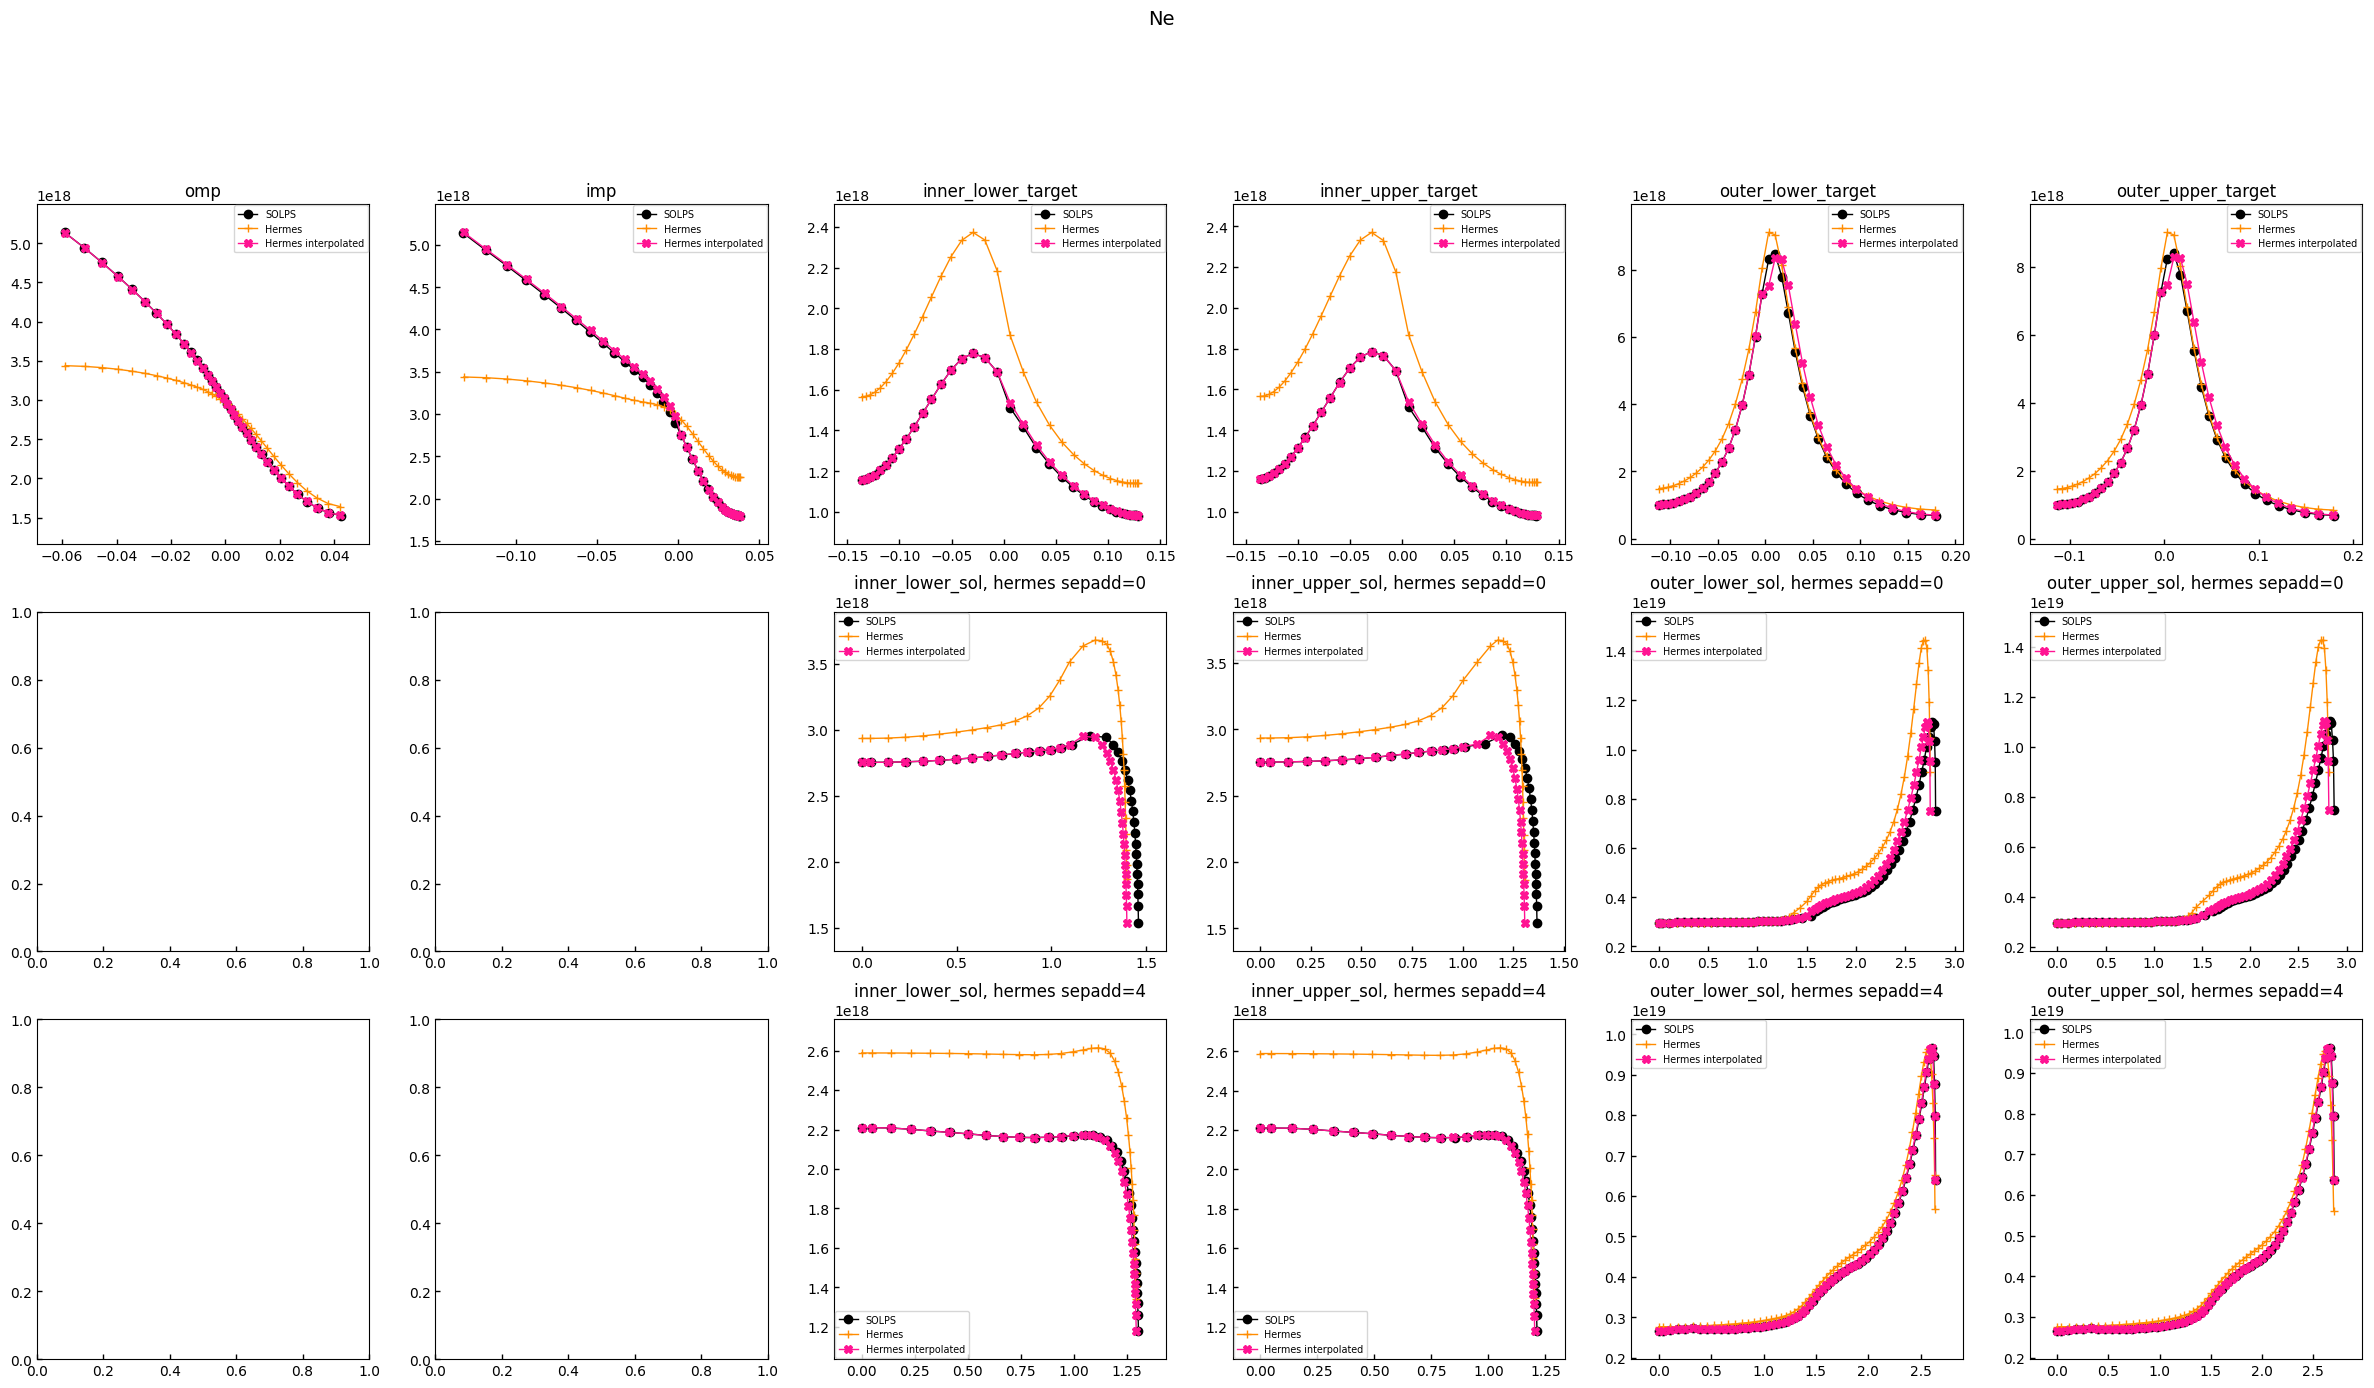

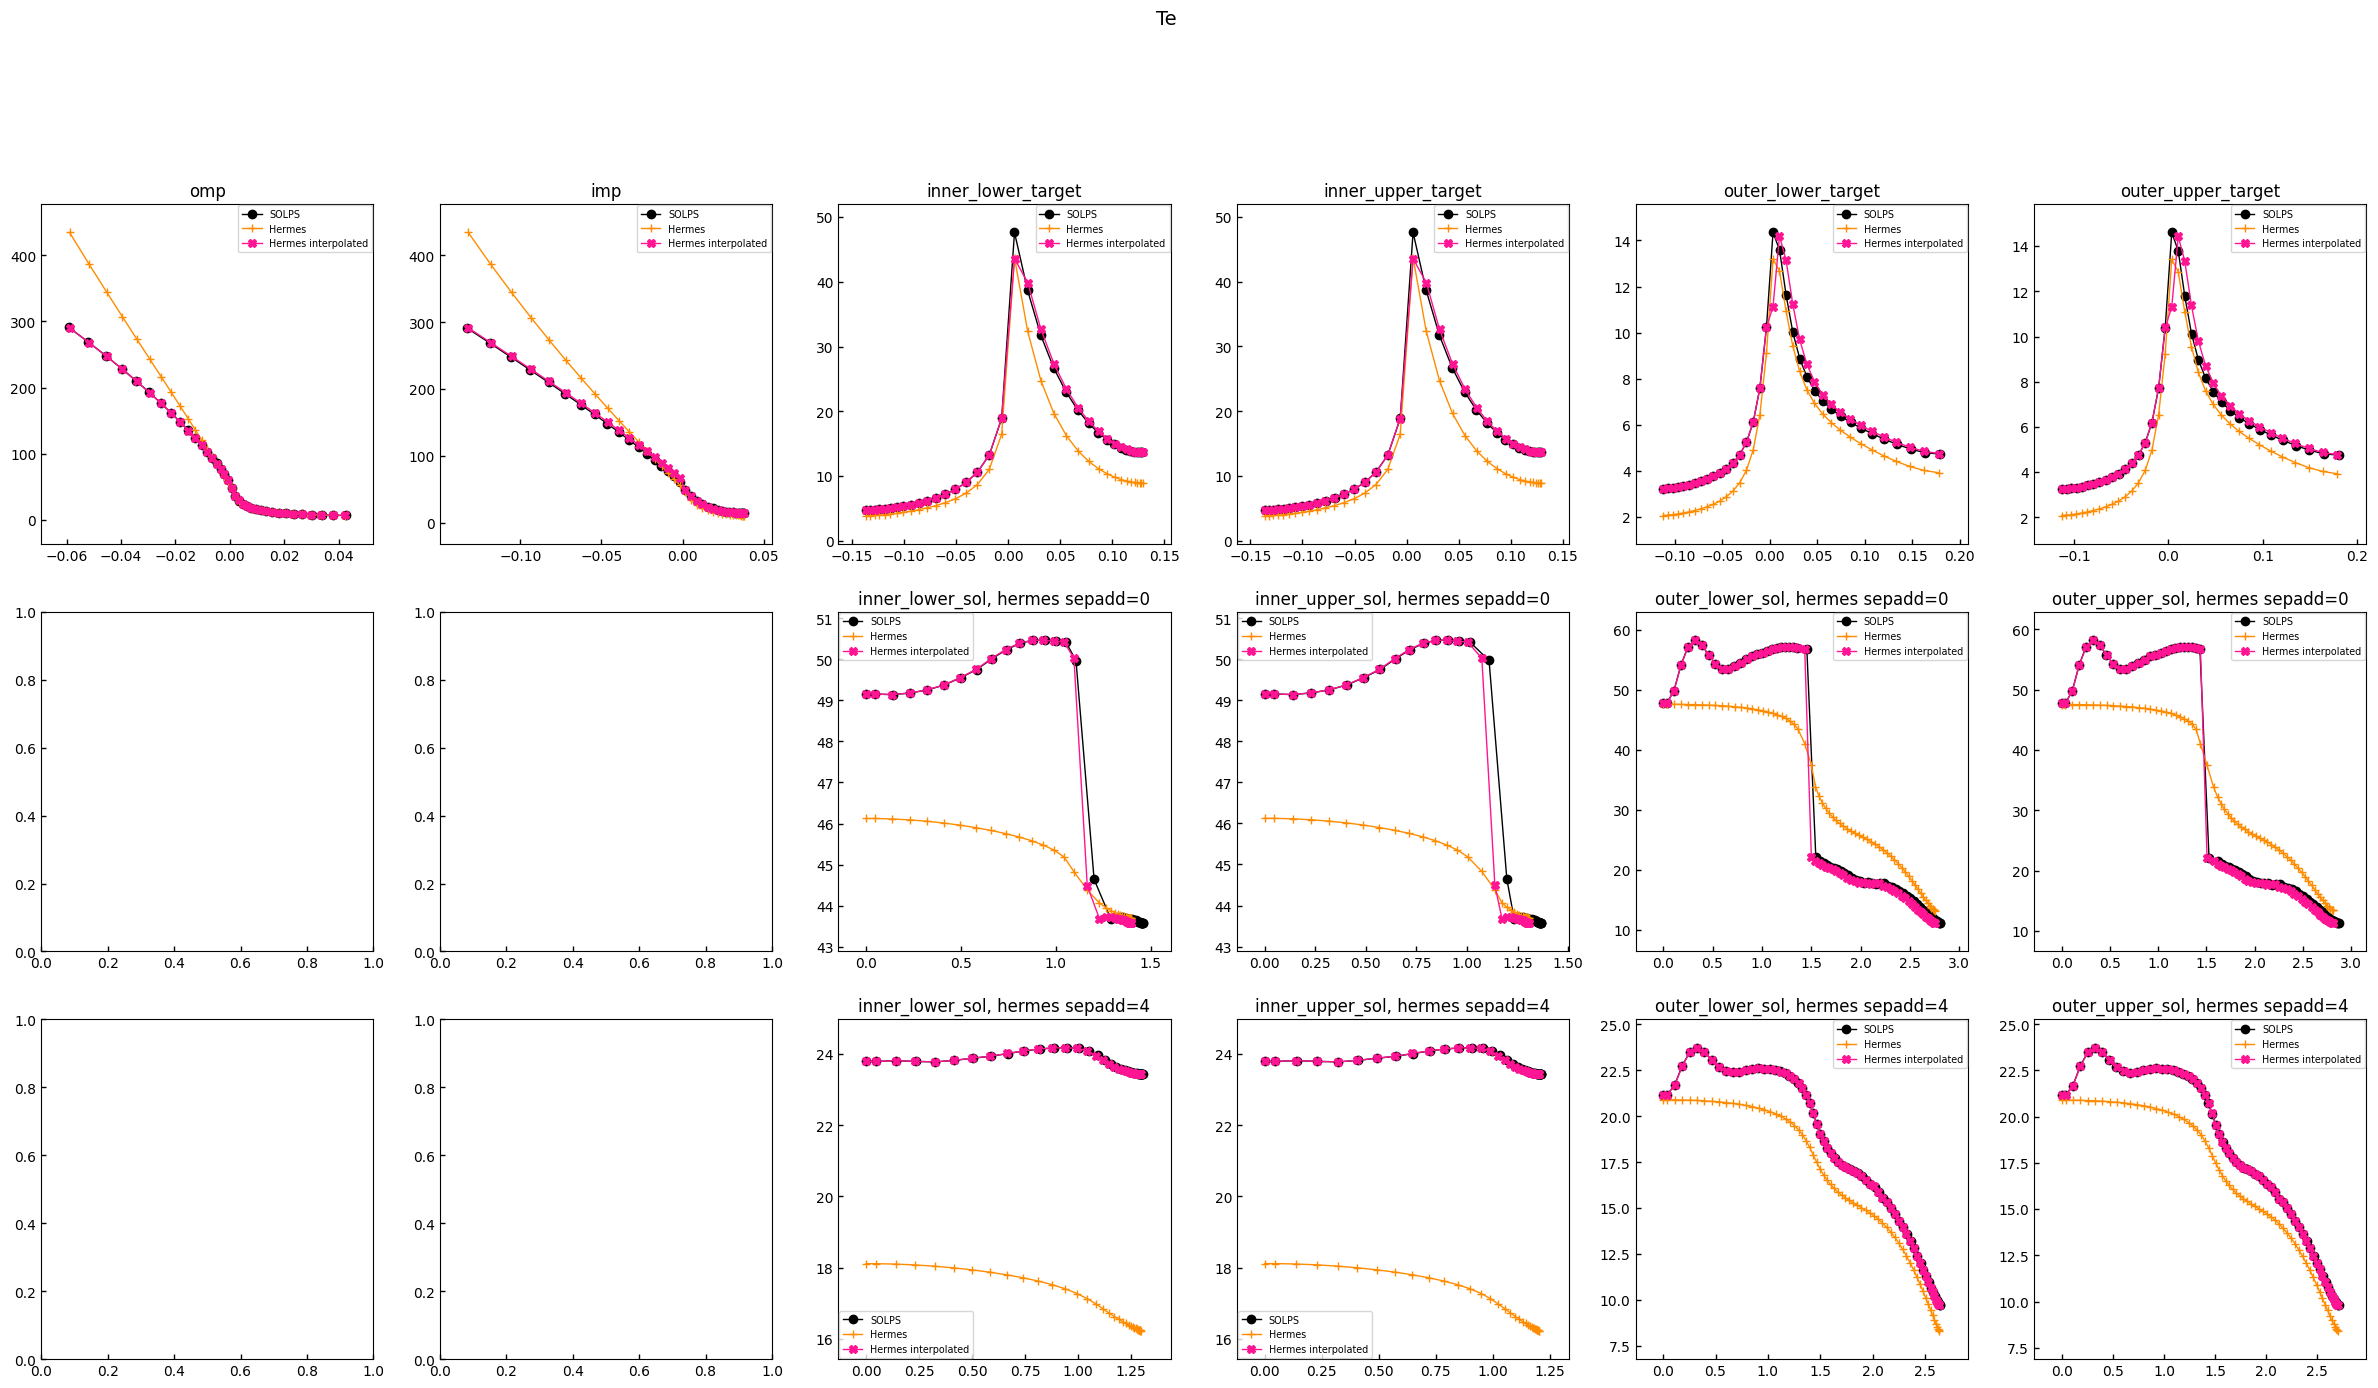

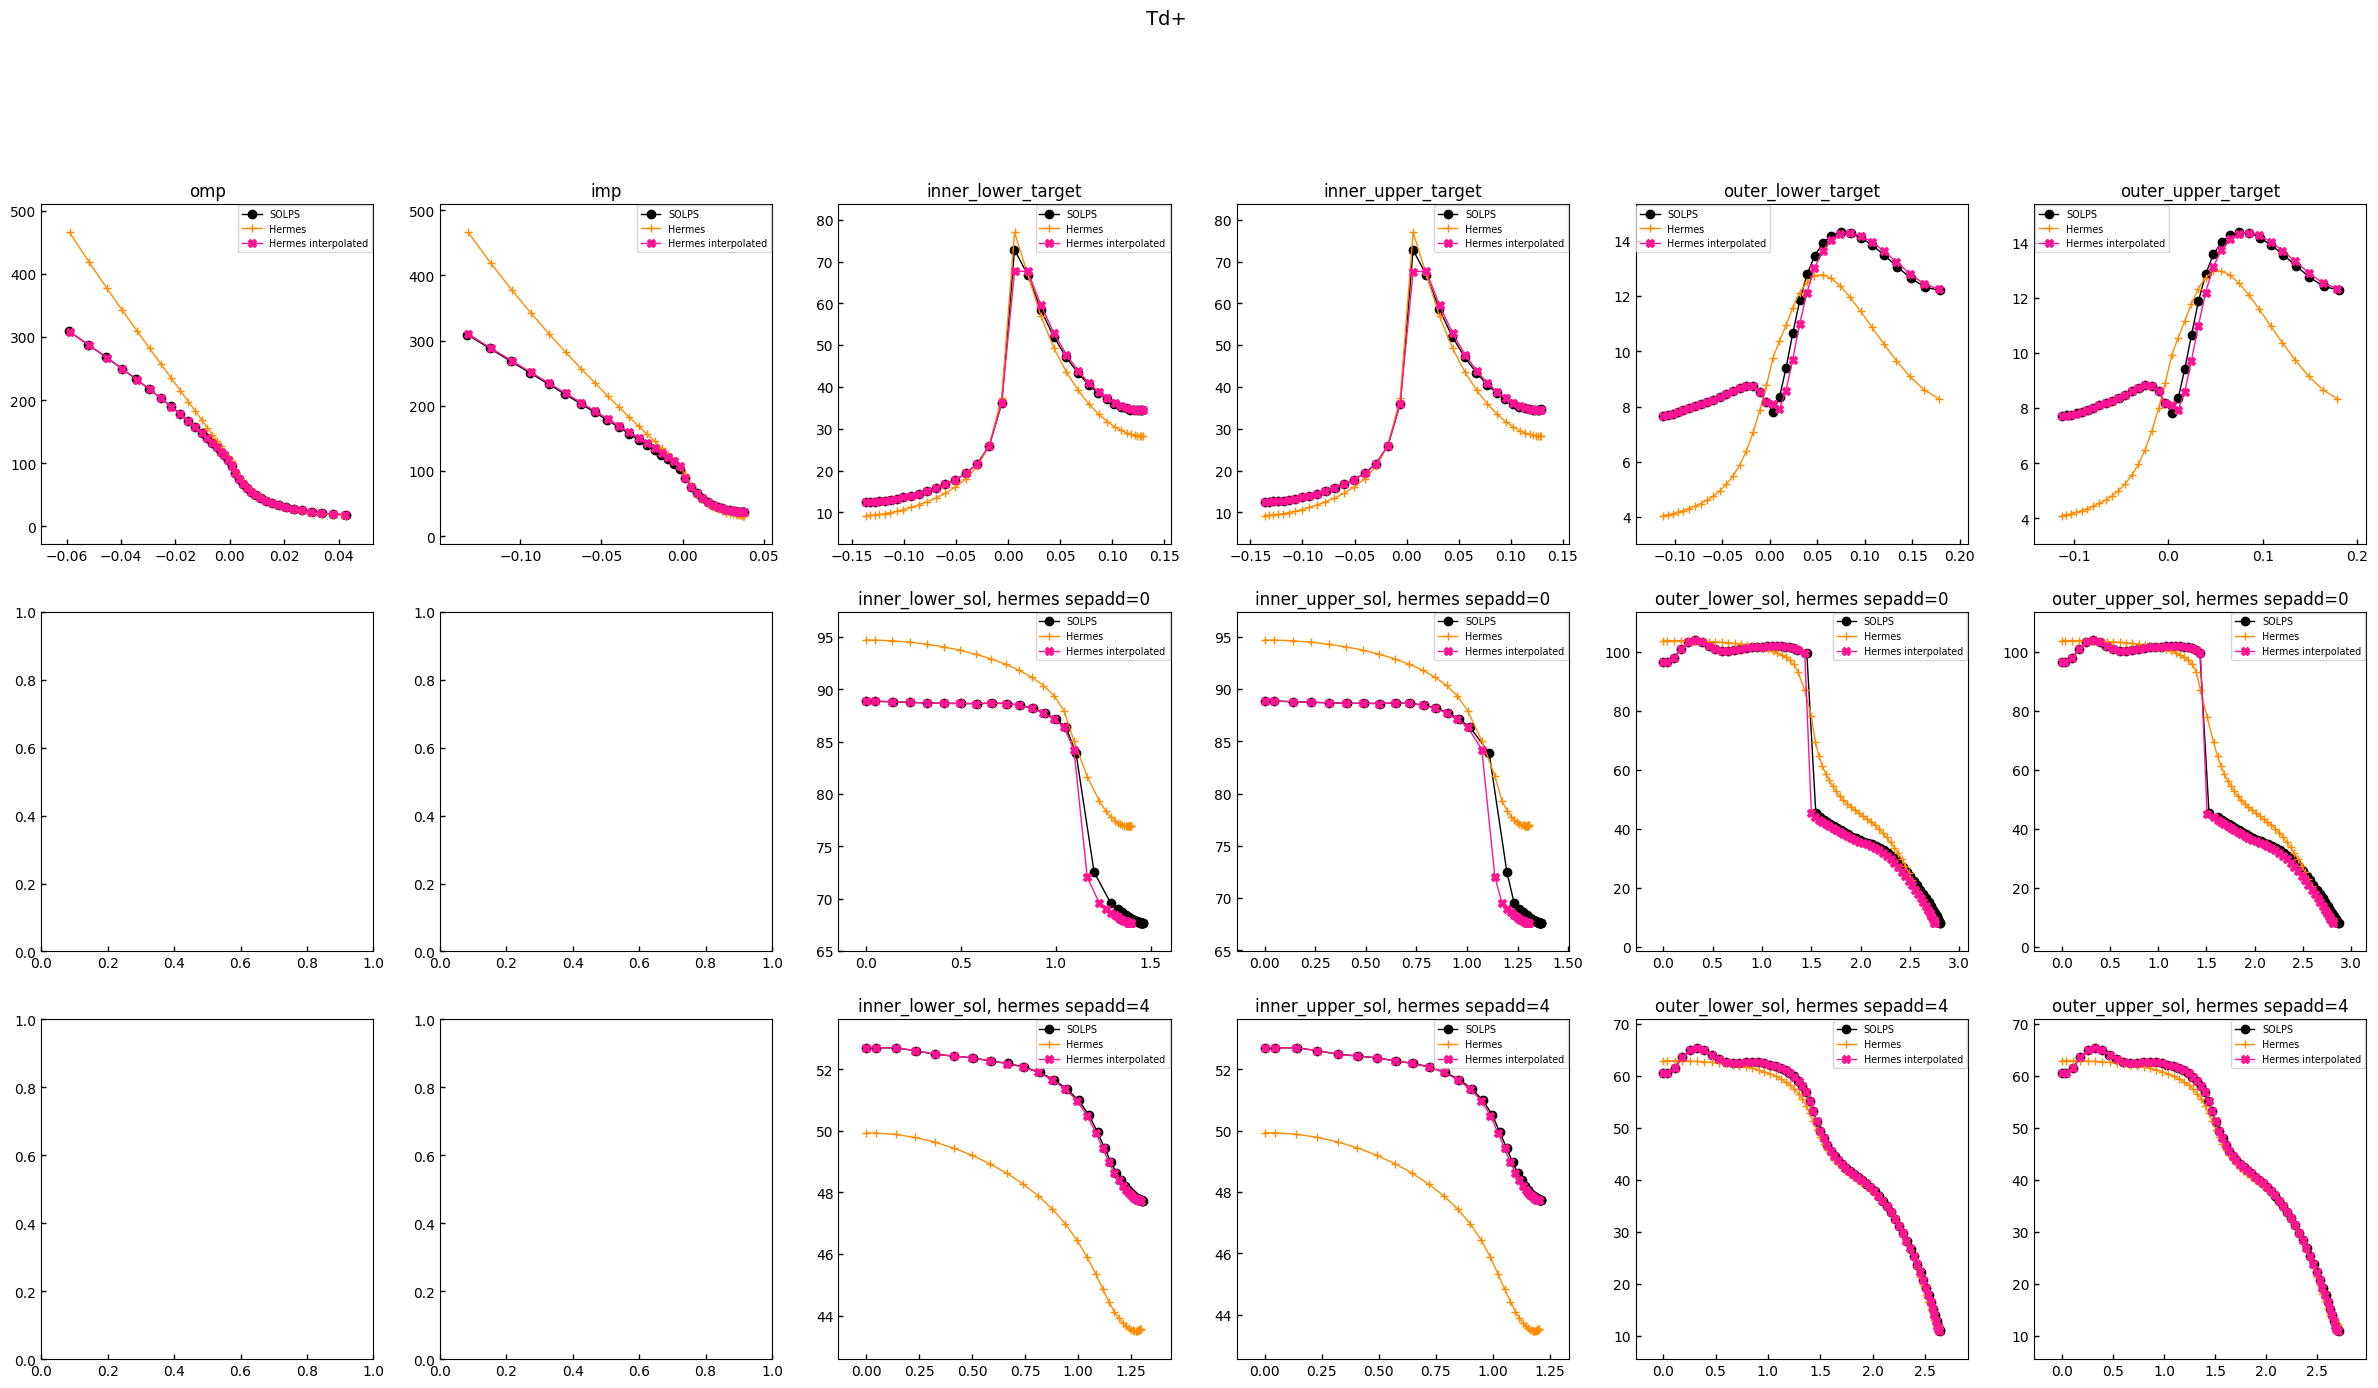

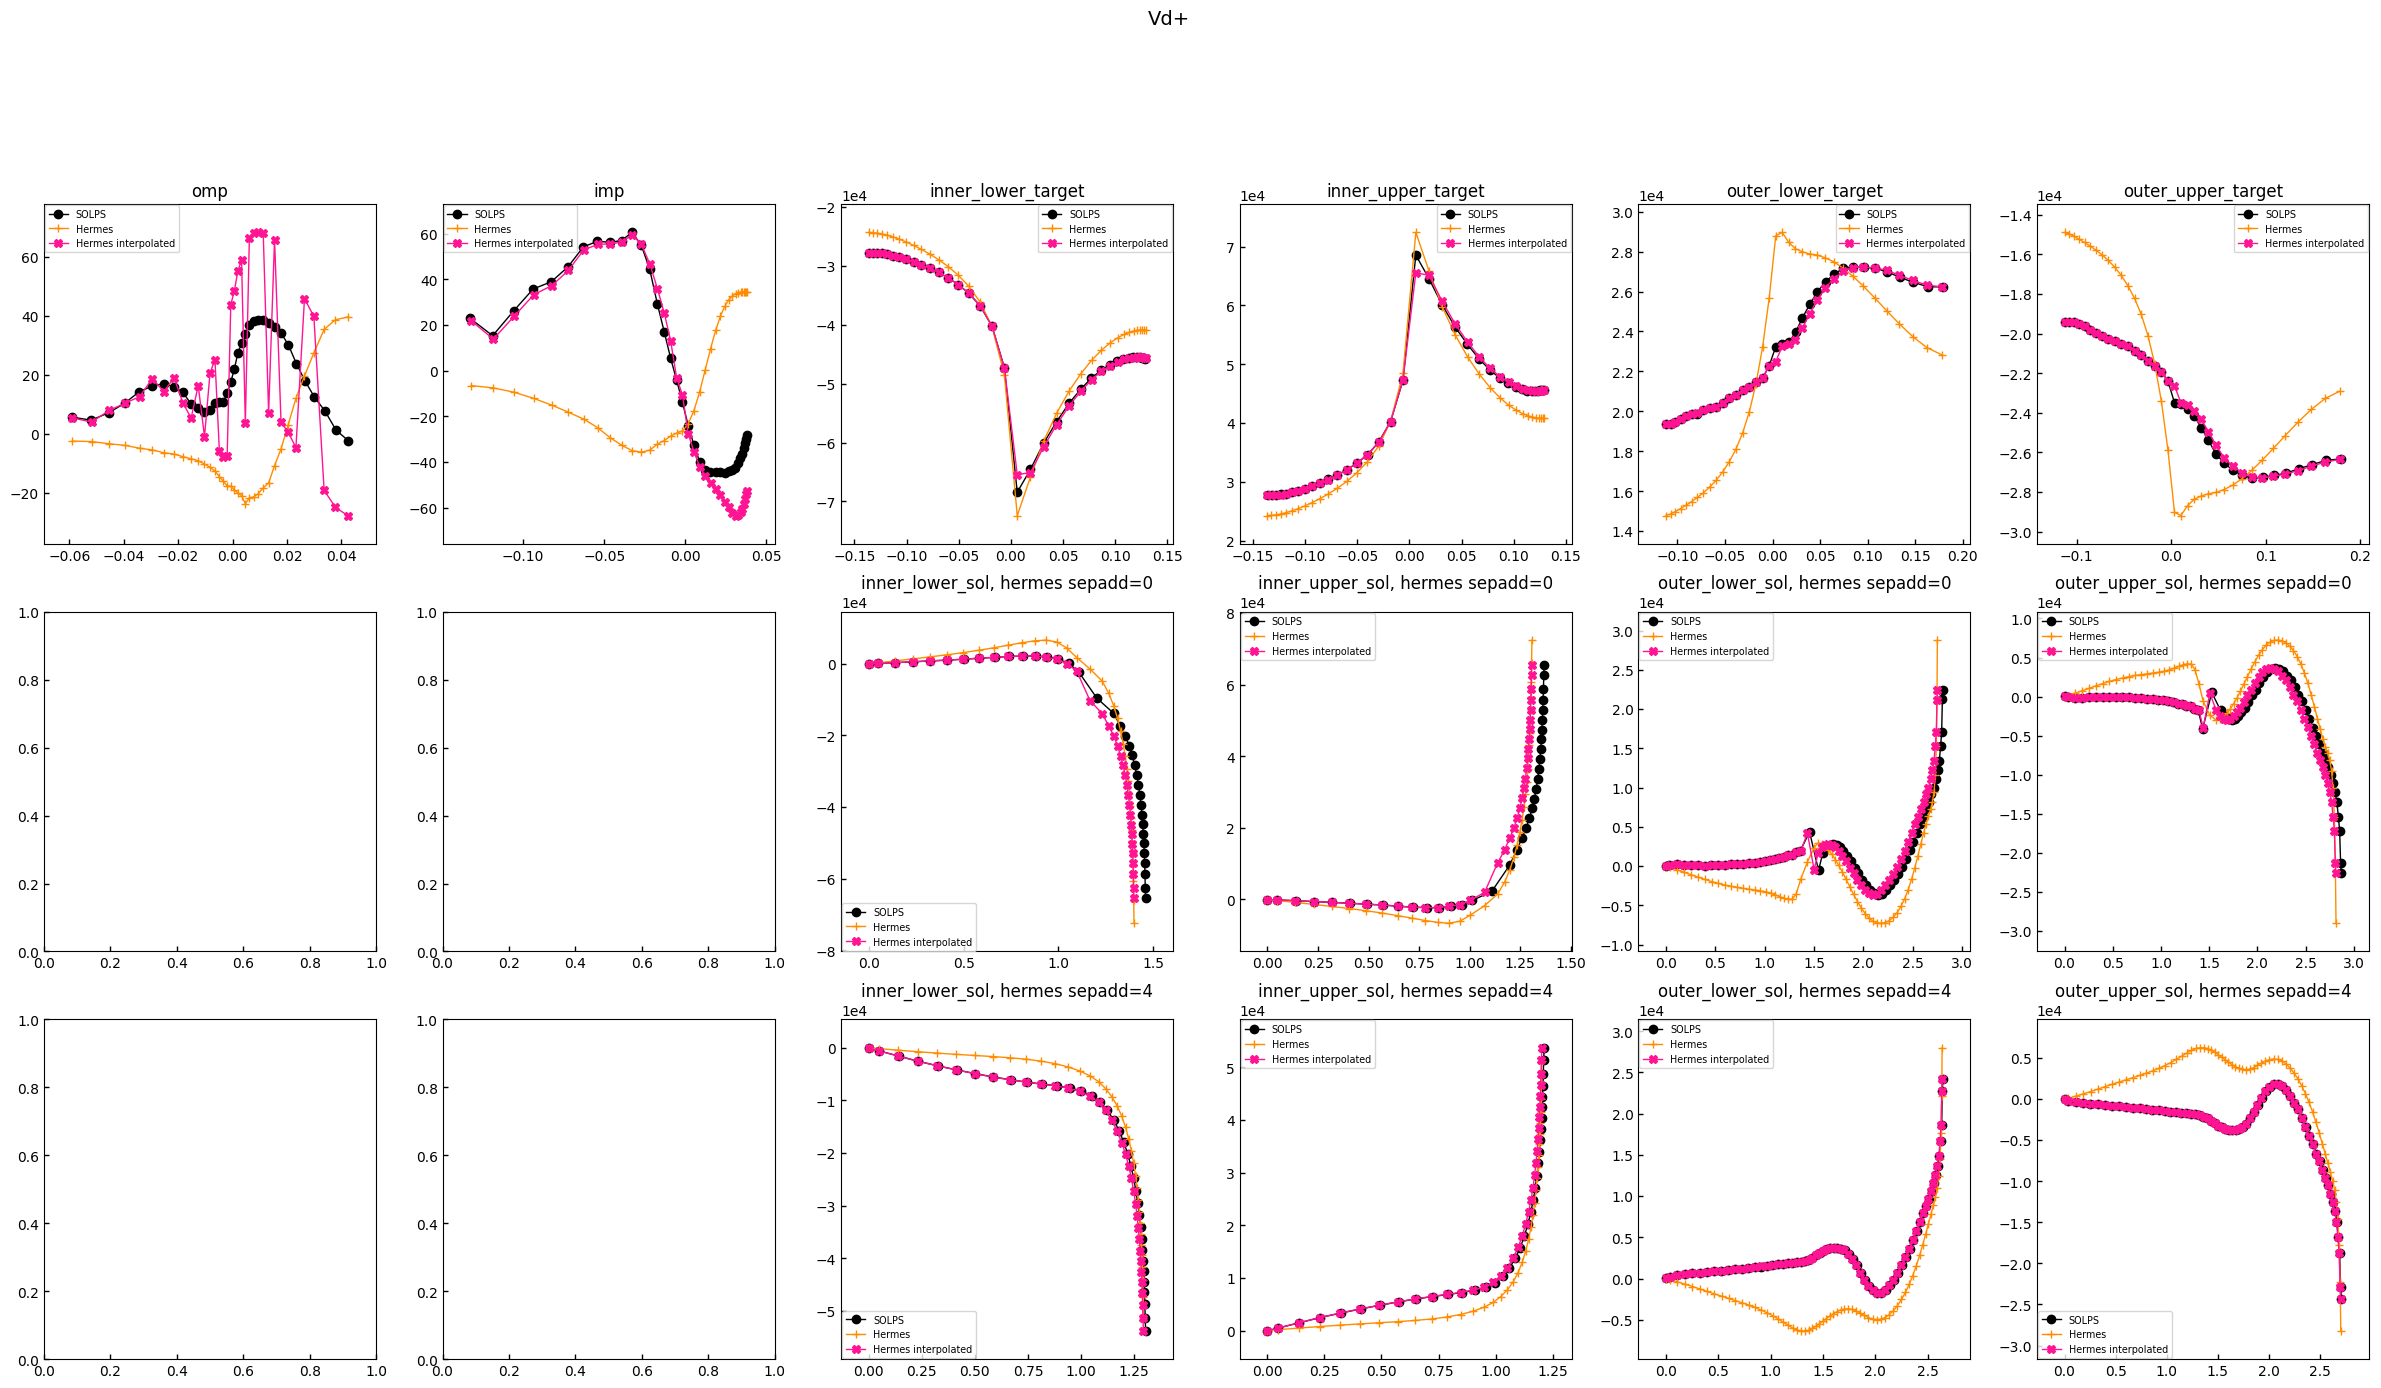

In [46]:
# ---------------------------------------------------------------- 5a. built-in 1D quality check
# Row 0: radial profiles at both midplanes and all four targets
# Rows 1-2: parallel profiles along SOL rings sepadd = 0 and 4
# black = SOLPS, orange = Hermes-3, pink = SOLPS interpolated onto Hermes-3 (should track black)
for p in PARAMS:
    interp.plot_1d_check(ds, p)
    plt.suptitle(p, y=1.01, fontsize=14)

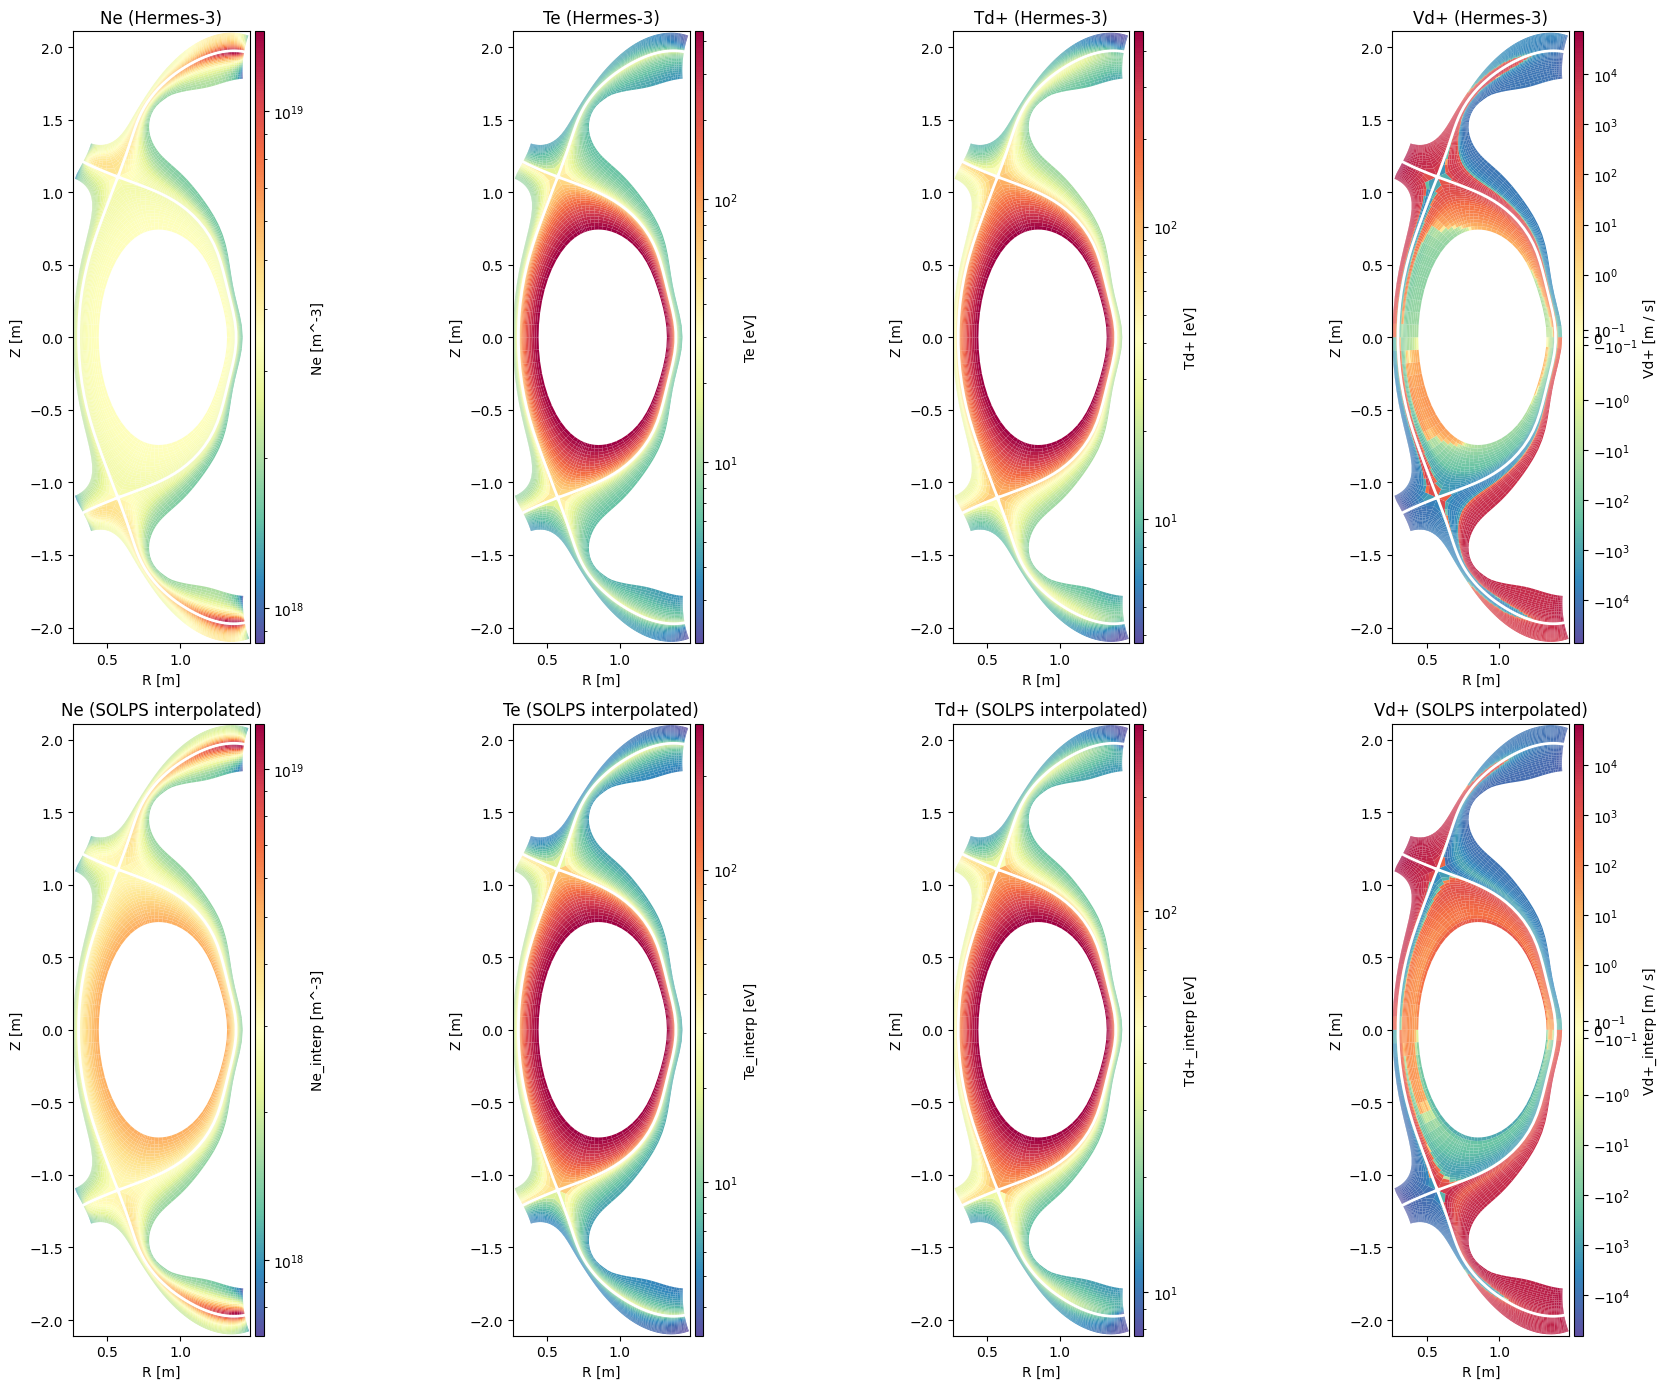

In [51]:
# ---------------------------------------------------------------- 5b. 2D maps: Hermes vs interpolated SOLPS
fig, axes = plt.subplots(2, len(PARAMS), figsize=(4.5 * len(PARAMS), 14), dpi=100)

for k, p in enumerate(PARAMS):
    logscale = p in ("Ne", "Te", "Td+", "Vd+")
    ds[p].hermes.clear_guards().bout.polygon(
        ax=axes[0, k], cmap="Spectral_r", logscale=logscale, separatrix=True, antialias=True
    )
    axes[0, k].set_title(f"{p} (Hermes-3)")

    ds[f"{p}_interp"].hermes.clear_guards().bout.polygon(
        ax=axes[1, k], cmap="Spectral_r", logscale=logscale, separatrix=True, antialias=True
    )
    axes[1, k].set_title(f"{p} (SOLPS interpolated)")

fig.tight_layout()

In [48]:
# ---------------------------------------------------------------- 6. fill the cells the interpolator never touched
# interpolate() starts from np.zeros_like(ds[param]) and only writes real cells of the 9 regions,
# so every guard cell is left at exactly 0. Zeros in a grid-file background are fatal, so
# Neumann-copy the guards. Use a mask from Ne (never legitimately 0) rather than testing ==0,
# so genuine Vd+ = 0 (stagnation) is not mistaken for a missing cell.

MXG = 2
MYG = int(m["MYG"])
ny_inner = int(m["ny_inner"])
nx, nyg = ds["Ne"].shape

written = ds["Ne_interp"].values != 0
print(f"interpolated {written.sum()} / {written.size} cells "
      f"({written.size - written.sum()} left to fill)")

# (guard rows, index of the domain row to copy from) for the four target boundaries
Y_GUARDS = [
    (slice(0, MYG), MYG),                                            # inner lower target
    (slice(ny_inner + MYG, ny_inner + 2 * MYG), ny_inner + MYG - 1),  # inner upper target
    (slice(ny_inner + 2 * MYG, ny_inner + 3 * MYG), ny_inner + 3 * MYG),  # outer upper target
    (slice(nyg - MYG, nyg), nyg - MYG - 1),                          # outer lower target
]


def fill_missing(arr, written, name=""):
    """Neumann-fill guard cells of an (x, theta) array; linear-fill anything still missing."""
    out = np.array(arr, dtype=float)
    out[~written] = np.nan

    # 1. poloidal guards: copy the adjacent domain row (still NaN in the x-guard corners)
    for gsl, src in Y_GUARDS:
        out[:, gsl] = out[:, src][:, None]

    # 2. radial guards: copy the adjacent domain ring - this also fixes the corners
    out[:MXG, :] = out[MXG, :][None, :]
    out[-MXG:, :] = out[-MXG - 1, :][None, :]

    # 3. anything still missing (rings with no SOLPS data): fill radially from valid neighbours
    n_bad = int(np.isnan(out).sum())
    if n_bad:
        print(f"  {name}: {n_bad} cells still missing after guard fill -> radial fill")
        xi = np.arange(out.shape[0])
        for j in range(out.shape[1]):
            col = out[:, j]
            good = np.flatnonzero(np.isfinite(col))
            if good.size == 0:
                raise ValueError(f"{name}: poloidal index {j} has no valid data at all")
            out[:, j] = np.interp(xi, good, col[good])

    assert np.isfinite(out).all(), f"{name}: NaNs remain"
    return out


# sanity check on the mask geometry: everything outside the domain must be unwritten
domain = np.zeros_like(written)
domain[MXG:-MXG, MYG:ny_inner + MYG] = True
domain[MXG:-MXG, ny_inner + 3 * MYG:nyg - MYG] = True
print("all written cells inside the domain:", bool((~domain & written).sum() == 0))
print("domain cells missing data:", int((domain & ~written).sum()))

interpolated 7200 / 8320 cells (1120 left to fill)
all written cells inside the domain: True
domain cells missing data: 0


In [52]:
# ---------------------------------------------------------------- 7. write the fields into a COPY of the grid
qe = constants("q_e")

Ne_bg = fill_missing(ds["Ne_interp"].values, written, "Ne")
Te_bg = fill_missing(ds["Te_interp"].values, written, "Te")
Ti_bg = fill_missing(ds["Td+_interp"].values, written, "Td+")
Vi_bg = fill_missing(ds["Vd+_interp"].values, written, "Vd+")

# Floors: Hermes-3 divides by N and T all over the place
Ne_bg = np.clip(Ne_bg, 1e13, None)      # m^-3
Te_bg = np.clip(Te_bg, 0.05, None)      # eV
Ti_bg = np.clip(Ti_bg, 0.05, None)      # eV

fields = {
    "solps_ni": Ne_bg,              # m^-3   -> [d+] density
    "solps_ti": Ti_bg,              # eV     -> [d+] temperature
    "solps_vi": Vi_bg,              # m/s    -> [d+] velocity
    "solps_te": Te_bg,              # eV     -> [e]  temperature
}


shutil.copyfile(GRID_IN, GRID_OUT)
mesh = Mesh(GRID_OUT)

for name, data in fields.items():
    assert data.shape == mesh.Rxy.shape, (name, data.shape, mesh.Rxy.shape)
    assert np.isfinite(data).all(), f"{name} contains NaN/inf"
    f = Field(name, mesh)
    f.data[:, :] = data           # in place: keeps the BoutArray + its attributes
    mesh.write_field(f, dtype="Field2D")

mesh.close()
print(f"\nWrote {len(fields)} fields to {GRID_OUT}")

>>> Field solps_ni already exists in /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_highrsl_6e20_solpsbg_260803.nc, it will be overwritten
-> Wrote field solps_ni to /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_highrsl_6e20_solpsbg_260803.nc
>>> Field solps_ti already exists in /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_highrsl_6e20_solpsbg_260803.nc, it will be overwritten
-> Wrote field solps_ti to /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_highrsl_6e20_solpsbg_260803.nc
>>> Field solps_vi already exists in /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_highrsl_6e20_solpsbg_260803.nc, it will be overwritten
-> Wrote field solps_vi to /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_highrsl_6e20_solpsbg_260803.nc
>>> Field solps_te already exists in /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_highrsl_6e20_solpsbg_260803.nc, it will be overwritten
-> Wrote field solps_te to /Use

field                 shape          min          max    zeros   NaNs
Nd+_init          (40, 208)   7.0005e+17   1.2352e+19        0      0
Ne_init           (40, 208)   7.0005e+17   1.2352e+19        0      0
Td+_init          (40, 208)   7.6634e+00   3.1085e+02        0      0
Te_init           (40, 208)   3.2303e+00   2.9269e+02        0      0
Pd+_init          (40, 208)   1.2410e+00   2.5680e+02        0      0
Pe_init           (40, 208)   5.2217e-01   2.4180e+02        0      0
Vd+0              (40, 208)  -6.5456e+04   6.5556e+04        0      0
Ve0               (40, 208)  -6.5456e+04   6.5556e+04        0      0
Mesh file /Users/zero/workspace/phd_work/hms_output/gridfile/CDN_46895_highrsl_6e20_solpsbg_260803.nc closed


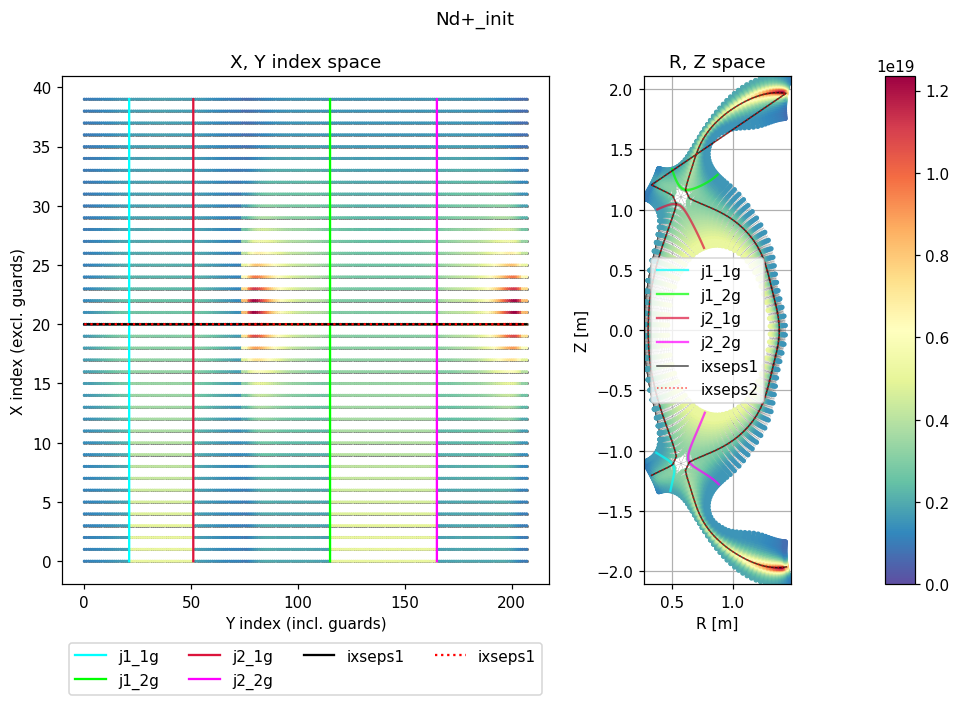

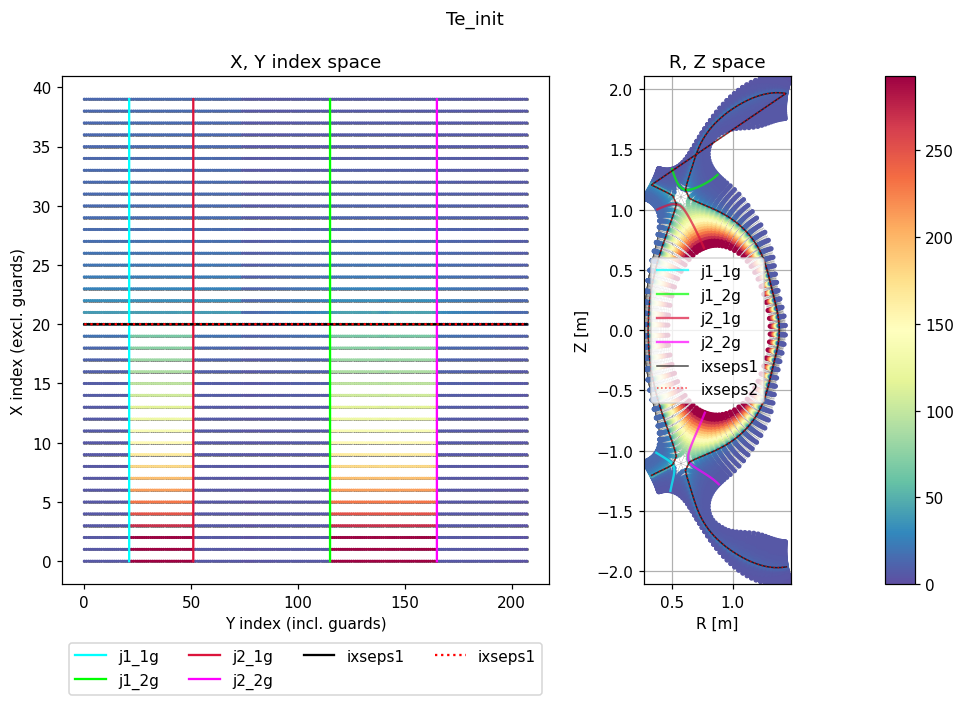

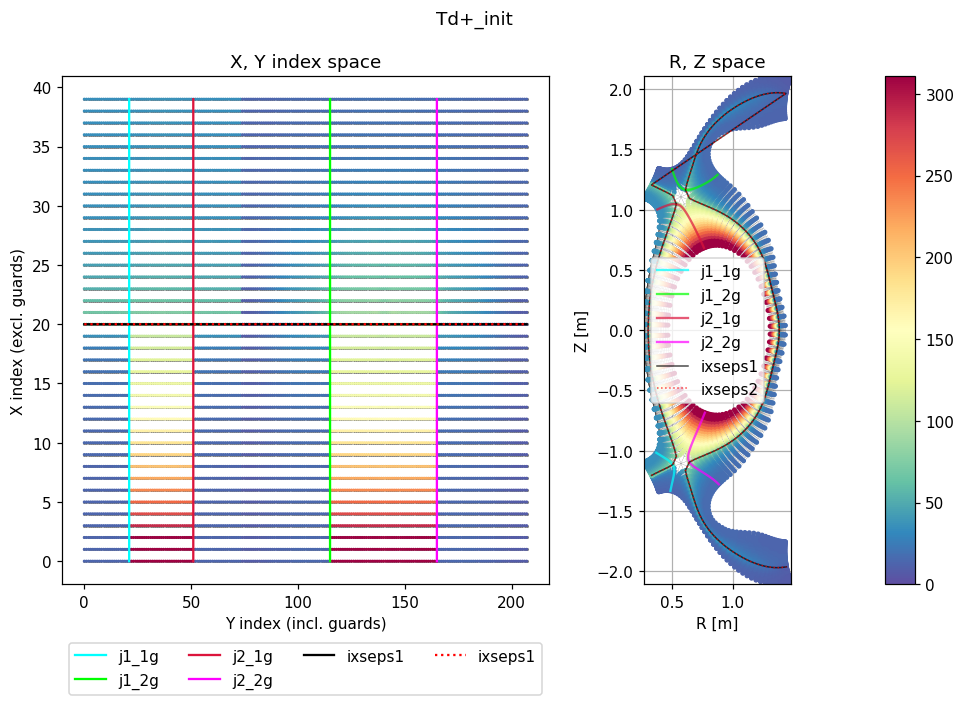

In [50]:
# ---------------------------------------------------------------- 8. verify what landed in the grid
check = Mesh(GRID_OUT)

print(f"{'field':12s} {'shape':>14s} {'min':>12s} {'max':>12s} {'zeros':>8s} {'NaNs':>6s}")
for name in fields:
    d = np.asarray(check.mesh[name], dtype=float)
    print(
        f"{name:12s} {str(d.shape):>14s} {d.min():12.4e} {d.max():12.4e} "
        f"{int((d == 0).sum()):8d} {int(np.isnan(d).sum()):6d}"
    )

# plot_field() colour-scales by field/max, so only use it on strictly positive fields
for name in ["Nd+_init", "Te_init", "Td+_init"]:
    check.plot_field(name)

check.close()

## 9. `BOUT.inp` to run it

```ini
[mesh]
file = "CDN_46895_lowresol_solpsbg.nc"     # grid written above

[hermes]
components = (d+, d, e, collisions, sheath_boundary_simple, recycling, sound_speed, reactions)

[d+]                            # FROZEN
type = fixed_density, fixed_temperature, fixed_velocity
AA = 2
charge = 1
density = 1e18                  # placeholder: .as<Field3D>() is evaluated unconditionally
initialize_from_mesh = true     # -> Nd+_init [m^-3]
temperature = 10                # placeholder (needs the patch in section 10)
# velocity NOT set -> fixed_velocity falls back to the grid field Vd+0 [m/s]
# keep all your recycle_as / *_recycle_* / neutral_pump options unchanged

[e]                             # FROZEN
type = quasineutral, fixed_temperature, zero_current
AA = 1/1836
charge = -1
temperature = 10
initialize_from_mesh = true     # -> Te_init [eV]

[d]                             # only evolving species - unchanged
type = neutral_mixed, neutral_boundary
```

* `[Nd+]`, `[Pd+]`, `[Pe]` sections become dead options (only `evolve_*` read them);
  `error_on_unused_options = false` is already set so they can stay.
* Solver state drops to `Nd, Pd, NVd` → old `BOUT.restart.*` files will not match, start fresh.

## 10. Caveats, and the one code change you need

### (a) `fixed_temperature` cannot read the grid file yet — this is the blocker

* `fixed_density` **can** (`initialize_from_mesh` → `N<name>_init`, and `N` is a `Field3D`).
* `fixed_velocity` **can** (always reads `V<name>0`, `V` is a `Field3D`).
* `fixed_temperature` has a `Field3D T` but **no** `initialize_from_mesh` hook.
* `isothermal` **has** the hook but declares `BoutReal T` (`include/isothermal.hxx:16`), so
  `mesh->get(T, "T<name>_init")` binds the **scalar** overload — it reads a scalar, never a 2D
  profile. Do not rely on it for a 2D background.

Minimal patch, mirroring `FixedDensity`, in `my-hermes-3/include/fixed_temperature.hxx`:

```cpp
#include "component.hxx"
#include <bout/constants.hxx>
#include <bout/globals.hxx>          // <-- add

    // ... in the constructor, after T is read from the option:
    T = options["temperature"].doc("Constant temperature [eV]").as<Field3D>() / Tnorm;

    // Initialise the Field3D T from 2D profiles stored in the mesh file.
    initialize_from_mesh =
        options["initialize_from_mesh"]
            .doc("Initialise field from 2D profiles stored in the mesh file?")
            .withDefault<bool>(false);

    if (initialize_from_mesh) {
      bout::globals::mesh->get(T, std::string("T") + name + "_init");  // Units: [eV]
      T /= Tnorm;                                                      // Normalisation
    }

    // ... and in the private members:
    bool initialize_from_mesh;
```

> `options["temperature"].as<Field3D>()` is evaluated **unconditionally**, exactly as
> `options["density"].as<Field3D>()` is in `fixed_density`. So you must still leave a dummy
> `temperature = ...` / `density = ...` in `BOUT.inp` even when `initialize_from_mesh = true`,
> or BOUT++ throws on a missing option.

### (b) Physics caveats of a frozen plasma

| Issue | Consequence |
|---|---|
| Plasma does not respond to neutrals | Ionisation/CX/recombination sources computed on the fixed plasma are a **one-way** sink/source for neutrals. Particle balance is not closed — the neutral solution relaxes to whatever the frozen plasma dictates. |
| Recycling | Still active: `recycling` reads the sheath ion flux from the fixed plasma, so the targets still emit neutrals at a fixed rate. This is normally exactly what you want for a background run. |
| `Vd+` sign | `SOLPScase` applies `self.momentum_sign = -1` (`solps_pp.py`, `__init__`) so positive points at the outer target. Check the sign of `Vd+_interp` at the outer target against the Hermes-3 `Vd+` in the QC plots before trusting it; flip with `solps.reverse_velocities()` if needed. |
| `Ne` vs `Nd+` | Only valid because there is a single main ion. With carbon in the mix, `Ne ≠ Nd+` and you must interpolate the ion density separately. |
| Guard cells | Neumann-copied here. That matches `bndry_all = neumann` for the plasma but is only an approximation at the sheath, where SOLPS itself has genuine guard values. |
| Interpolation coverage | Rings outside the SOLPS radial extent are edge-clamped (`_interpolate_values` uses `fill_value=(y[0], y[-1])`) and radial extrapolation is on (`extrapolate_radial=True`). Check the outermost SOL ring in the QC plots. |

### (c) If you would rather start the plasma from SOLPS but still evolve it

Same grid fields, different input: keep `type = evolve_density, evolve_pressure, ...` and set
`initialize_from_mesh = true` under `[Nd+]` (reads `Nd+_init`) and `[Pd+]`/`[Pe]`
(reads `Pd+_init`/`Pe_init`, in **Pa**). That path is already supported with no code change —
see `src/evolve_density.cxx:155` and `src/evolve_pressure.cxx:175`.